# UAPOML
# Assignment - 2

## Problem 1:
### Portfolio Construction & Daily Returns

In [728]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###  Problem 1(a)

Creating the prices_df DataFrame.

Formula Used:

Rt = (Pt - Pt-1) / Pt-1

where:

Rt = daily return  
Pt = current day price  
Pt-1 = previous day price

In [729]:
# Creating prices dataframe

data = {
    "RELIANCE": [2800, 2850, 2830, 2900, 2880, 2950],
    "INFY": [1450, 1470, 1460, 1490, 1510, 1500],
    "HDFCBANK": [1600, 1580, 1610, 1625, 1615, 1640],
    "TATAMOTORS": [520, 535, 528, 540, 555, 548]
}

prices_df = pd.DataFrame(
    data,
    index=["Day1", "Day2", "Day3", "Day4", "Day5", "Day6"]
)

print("Prices DataFrame")
prices_df

Prices DataFrame


,RELIANCE,INFY,HDFCBANK,TATAMOTORS
Day1,2800,1450,1600,520
Day2,2850,1470,1580,535
Day3,2830,1460,1610,528
Day4,2900,1490,1625,540
Day5,2880,1510,1615,555
Day6,2950,1500,1640,548


Computing daily percentage returns using pct_change().

In [730]:
# Computing daily percentage returns

returns_df = prices_df.pct_change()

print("Daily Percentage Returns")
returns_df

Daily Percentage Returns


,RELIANCE,INFY,HDFCBANK,TATAMOTORS
Day1,NaN,NaN,NaN,NaN
Day2,0.017857,0.013793,-0.012500,0.028846
Day3,-0.007018,-0.006803,0.018987,-0.013084
Day4,0.024735,0.020548,0.009317,0.022727
Day5,-0.006897,0.013423,-0.006154,0.027778
Day6,0.024306,-0.006623,0.015480,-0.012613


### Problem 1(b)

Computing units purchased and daily portfolio value.

Formulas Used:

Allocation = Initial Capital × Weights

Units Purchased = Allocation / Day1 Price

Portfolio Value = prices_df.dot(units)

In [731]:
# Initial capital

initial_capital = 1000000

# Equal weights

weights = np.array([0.25, 0.25, 0.25, 0.25])

print("Weights")
print(weights)

Weights
[0.25 0.25 0.25 0.25]


In [732]:
# Allocation for each asset

allocation = initial_capital * weights

print("Allocation")
print(allocation)

Allocation
[250000. 250000. 250000. 250000.]


In [733]:
# Day 1 prices

first_day_prices = prices_df.iloc[0]

print("Day 1 Prices")
print(first_day_prices)

Day 1 Prices
RELIANCE      2800
INFY          1450
HDFCBANK      1600
TATAMOTORS     520
Name: Day1, dtype: int64


In [734]:
# Computing units purchased

units = allocation / first_day_prices

print("Units Purchased")
units

Units Purchased


,Day1
RELIANCE,89.285714
INFY,172.413793
HDFCBANK,156.250000
TATAMOTORS,480.769231


In [735]:
# Computing portfolio value using vectorised approach

portfolio_values = prices_df.dot(units)

print("Portfolio Values")
portfolio_values

Portfolio Values


,0
Day1,1.000000e+06
Day2,1.011999e+06
Day3,1.009811e+06
Day4,1.029347e+06
Day5,1.036658e+06
Day6,1.041725e+06


Plotting portfolio value over time.


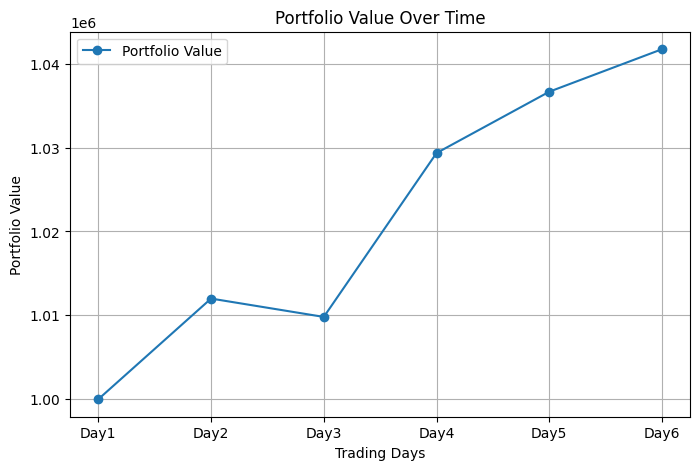

In [736]:
plt.figure(figsize=(8,5))

plt.plot(
    portfolio_values.index,
    portfolio_values.values,
    marker='o',
    label='Portfolio Value'
)

plt.title("Portfolio Value Over Time")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

### Problem 1(c)

Computing annualised volatility.

Formula Used:

Annualised Volatility = Daily Volatility × √252

In [737]:
# Portfolio daily returns

portfolio_returns = portfolio_values.pct_change().dropna()

print("Portfolio Returns")
portfolio_returns

Portfolio Returns


,0
Day2,0.011999
Day3,-0.002162
Day4,0.019346
Day5,0.007103
Day6,0.004888


In [738]:
# Daily volatility

daily_volatility = portfolio_returns.std()

print("Daily Volatility")
print(daily_volatility)

Daily Volatility
0.008034199876278432


In [739]:
# Annualised volatility

annualised_volatility = daily_volatility * np.sqrt(252)

print("Annualised Volatility")
print(annualised_volatility)

Annualised Volatility
0.12753896913611182


## Problem 2:
#### Risk Metrics — VaR, CVaR and Drawdowns

### Problem 2(a)

Generating synthetic returns using NumPy.

Given:

μ = 0.001  
σ = 0.015

Formula Used:

R ~ N(μ, σ)

Historical VaR Formula:

VaRα = - percentile(R, 1 - α)

In [740]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [741]:
# Setting random seed

np.random.seed(42)

In [742]:
# Generating 50 synthetic daily returns

mu = 0.001
sigma = 0.015

returns = np.random.normal(
    loc=mu,
    scale=sigma,
    size=50
)

returns = pd.Series(returns)

print("Synthetic Returns")
returns.head()

Synthetic Returns


,0
0,0.008451
1,-0.001074
2,0.010715
3,0.023845
4,-0.002512


Computing Historical VaR at 95% and 99% confidence levels.


In [743]:
# Computing VaR

VaR_95 = -np.percentile(returns, 5)
VaR_99 = -np.percentile(returns, 1)

print("VaR at 95% Confidence Level =", VaR_95)
print("VaR at 99% Confidence Level =", VaR_99)

VaR at 95% Confidence Level = 0.025188276651205526
VaR at 99% Confidence Level = 0.028054086245915096


#### Interpretation

VaR at 95% means that there is only a 5% chance that the portfolio loss will exceed this value in one day.

VaR at 99% means that there is only a 1% chance that the portfolio loss will exceed this value in one day.

### Problem 2(b)

Computing Conditional Value at Risk (CVaR).

Formula Used:

CVaR = Average loss beyond VaR threshold

In [744]:
# Computing CVaR

CVaR_95 = -returns[returns <= -VaR_95].mean()

CVaR_99 = -returns[returns <= -VaR_99].mean()

print("CVaR at 95% Confidence Level =", CVaR_95)
print("CVaR at 99% Confidence Level =", CVaR_99)

CVaR at 95% Confidence Level = 0.027179952619501537
CVaR at 99% Confidence Level = 0.028395051858196633


##### Why CVaR is More Informative

VaR only tells the minimum loss threshold at a confidence level.

CVaR measures the average loss during extreme bad cases beyond VaR.

Therefore, CVaR gives better information about tail risk.

### Problem 2(c)

Computing Maximum Drawdown (MaxDD).

Formula Used:

Drawdownt = (Peak Value - Current Value) / Peak Value

Maximum Drawdown = Maximum value of drawdown series

In [745]:
# Creating portfolio value series

initial_value = 1000000

portfolio_values = initial_value * (1 + returns).cumprod()

print("Portfolio Values")
portfolio_values.head()

Portfolio Values


,0
0,1.008451e+06
1,1.007368e+06
2,1.018162e+06
3,1.042440e+06
4,1.039822e+06


In [746]:
# Computing running peak

running_peak = portfolio_values.cummax()

print("Running Peak")
running_peak.head()

Running Peak


,0
0,1.008451e+06
1,1.008451e+06
2,1.018162e+06
3,1.042440e+06
4,1.042440e+06


In [747]:
# Computing drawdown

drawdown = (running_peak - portfolio_values) / running_peak

print("Drawdown")
drawdown.head()

Drawdown


,0
0,0.000000
1,0.001074
2,0.000000
3,0.000000
4,0.002512


In [748]:
# Computing maximum drawdown

max_drawdown = drawdown.max()

print("Maximum Drawdown =", max_drawdown)

Maximum Drawdown = 0.1816487721165461


Plotting drawdown curve.

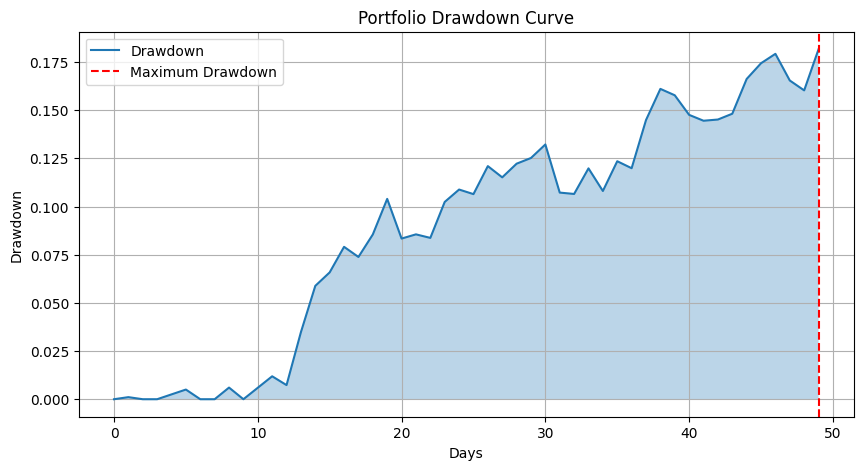

In [749]:
plt.figure(figsize=(10,5))

plt.plot(drawdown.values, label='Drawdown')

plt.fill_between(range(len(drawdown)),
                 drawdown.values,
                 alpha=0.3)

max_dd_day = drawdown.idxmax()

plt.axvline(x=max_dd_day,
            color='red',
            linestyle='--',
            label='Maximum Drawdown')

plt.title("Portfolio Drawdown Curve")
plt.xlabel("Days")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(True)

plt.show()

## Problem 3:

### Risk-Adjusted Performance Metrics

###### We use the synthetic portfolio returns generated in Problem 2.
###### Risk-free rate is given as 6% per annum.

###### Risk-free rate per day
###### Rf = 0.06 / 252

###### Sharpe Ratio Formula:
###### Sharpe Ratio = (Rp - Rf) / σp

###### where:
###### Rp  = Annualised portfolio return
###### Rf  = Risk-free rate
###### σp  = Annualised volatility

###### Sortino Ratio Formula:
###### Sortino Ratio = (Rp - Rf) / σd

###### where:
###### σd = Downside deviation
######     (standard deviation of only negative returns)
######

### Part (a) : Sharpe Ratio


In [750]:
# Generating synthetic returns for Problem 3

synthetic_returns = np.random.normal(
    loc=0.001,
    scale=0.015,
    size=252
)

In [751]:
rf_daily = 0.06 / 252

# Annualised portfolio return
annual_return = synthetic_returns.mean() * 252

# Annualised volatility
annual_volatility = synthetic_returns.std() * np.sqrt(252)

# Sharpe Ratio
sharpe_ratio = (annual_return - 0.06) / annual_volatility

print("Annualised Return =", annual_return)
print("Annualised Volatility =", annual_volatility)
print("Sharpe Ratio =", sharpe_ratio)

Annualised Return = 0.37529927230973714
Annualised Volatility = 0.23483869777709065
Sharpe Ratio = 1.342620595729158



#### Interpretation of Sharpe Ratio


#### Sharpe Ratio measures excess return earned
#### per unit of total risk.

#### Higher Sharpe Ratio indicates better
#### risk-adjusted performance.

#### Sharpe Ratio considers both upside and
#### downside volatility.

### Part (b) : Sortino Ratio

In [752]:
# Selecting only negative returns
negative_returns = synthetic_returns[synthetic_returns < 0]

# Downside deviation
downside_deviation = negative_returns.std() * np.sqrt(252)

# Sortino Ratio
sortino_ratio = (annual_return - 0.06) / downside_deviation

print("Downside Deviation =", downside_deviation)
print("Sortino Ratio =", sortino_ratio)

Downside Deviation = 0.1311604249691485
Sortino Ratio = 2.4039207892464645



#####  Why Sortino Ratio Penalises Less


##### Sortino Ratio uses only downside volatility.

##### Positive volatility (high gains) is not treated
##### as harmful risk.

##### Therefore, portfolios with large positive returns
##### usually get a higher Sortino Ratio compared to
##### Sharpe Ratio.

### Part (c) : Comparison of Ratios


In [753]:
comparison_df = pd.DataFrame({
    "Metric": ["Sharpe Ratio", "Sortino Ratio"],
    "Value": [sharpe_ratio, sortino_ratio]
})

comparison_df

,Metric,Value
0,Sharpe Ratio,1.342621
1,Sortino Ratio,2.403921


##### Conclusion
##### Sortino Ratio is more appropriate for
##### asymmetrical return strategies because it
##### focuses only on downside risk.

##### Sharpe Ratio considers total volatility,
##### including positive volatility.

## Problem 4 :
### Backtesting a Simple Moving Average Strategy



###### We generate 200 days of synthetic stock prices
###### using a random walk model.

###### Formula:
###### Pt = Pt-1 * (1 + et)

###### where:
###### et ~ N(0.001, 0.018)

###### Initial Price:
###### P0 = 1000

###### Strategy:
###### Buy  (+1) when SMA_10 > SMA_30
###### Sell (-1) when SMA_10 < SMA_30

In [754]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Generating random returns
random_returns = np.random.normal(0.001, 0.018, 200)

# Generating price series
prices = [1000]

for r in random_returns:
    prices.append(prices[-1] * (1 + r))

prices = prices[1:]

# Creating DataFrame
df = pd.DataFrame({
    "Price": prices
})

df.head()

,Price
0,1009.940855
1,1008.437298
2,1021.202494
3,1050.219491
4,1046.843286


### Part (a) : SMA Crossover Strategy #####

###### SMA_10 = 10-day moving average
###### SMA_30 = 30-day moving average

###### Trading Signals:
###### +1 -> Buy
###### -1 -> Sell
######  0 -> Hold

In [755]:
# Calculating moving averages

df["SMA_10"] = df["Price"].rolling(window=10).mean()

df["SMA_30"] = df["Price"].rolling(window=30).mean()

# Generating signals
df["Signal"] = 0

df.loc[df["SMA_10"] > df["SMA_30"], "Signal"] = 1

df.loc[df["SMA_10"] < df["SMA_30"], "Signal"] = -1

df.head(35)

,Price,SMA_10,SMA_30,Signal
0,1009.940855,NaN,NaN,0
1,1008.437298,NaN,NaN,0
2,1021.202494,NaN,NaN,0
3,1050.219491,NaN,NaN,0
4,1046.843286,NaN,NaN,0
5,1043.478245,NaN,NaN,0
6,1074.183459,NaN,NaN,0
7,1090.096225,NaN,NaN,0
8,1081.974421,NaN,NaN,0
9,1093.623045,1051.999882,NaN,0


### Part (b) : Backtesting the Strategy #####

###### Initial Capital = 1,00,000

###### We compute:
###### 1. Strategy cumulative returns
###### 2. Buy-and-Hold cumulative returns

###### Both are plotted on the same graph.

In [756]:
# Daily returns
df["Returns"] = df["Price"].pct_change()

# Strategy returns
df["Strategy_Returns"] = df["Signal"].shift(1) * df["Returns"]

# Cumulative returns
df["Buy_Hold"] = (1 + df["Returns"]).cumprod()

df["Strategy"] = (1 + df["Strategy_Returns"]).cumprod()

df.head()

,Price,SMA_10,SMA_30,Signal,Returns,Strategy_Returns,Buy_Hold,Strategy
0,1009.940855,NaN,NaN,0,NaN,NaN,NaN,NaN
1,1008.437298,NaN,NaN,0,-0.001489,-0.0,0.998511,1.0
2,1021.202494,NaN,NaN,0,0.012658,0.0,1.011151,1.0
3,1050.219491,NaN,NaN,0,0.028415,0.0,1.039882,1.0
4,1046.843286,NaN,NaN,0,-0.003215,-0.0,1.036539,1.0


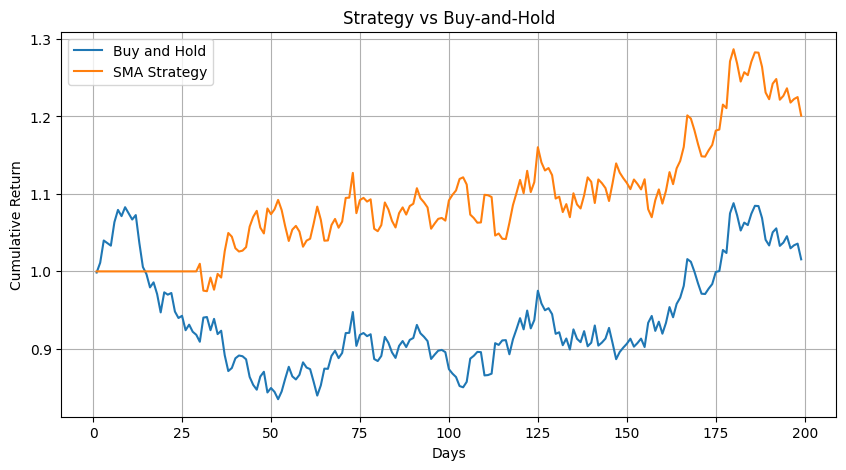

In [757]:
plt.figure(figsize=(10,5))

plt.plot(df["Buy_Hold"], label="Buy and Hold")

plt.plot(df["Strategy"], label="SMA Strategy")

plt.title("Strategy vs Buy-and-Hold")

plt.xlabel("Days")

plt.ylabel("Cumulative Return")

plt.legend()

plt.grid(True)

plt.show()

### Part (c) : Win Rate and Profit Factor #####

###### Win Rate Formula:
###### Winning Trades / Total Trades

###### Profit Factor Formula:
###### Total Profit / Total Loss

In [758]:
# Winning trades
winning_trades = (df["Strategy_Returns"] > 0).sum()

# Total trades
total_trades = (df["Strategy_Returns"] != 0).sum()

# Win rate
win_rate = winning_trades / total_trades

# Total profit
total_profit = df.loc[
    df["Strategy_Returns"] > 0,
    "Strategy_Returns"
].sum()

# Total loss
total_loss = abs(
    df.loc[
        df["Strategy_Returns"] < 0,
        "Strategy_Returns"
    ].sum()
)

# Profit factor
profit_factor = total_profit / total_loss

print("Win Rate =", win_rate)

print("Profit Factor =", profit_factor)

Win Rate = 0.52046783625731
Profit Factor = 1.2001554037593762


### Conclusion #####

###### Profit Factor > 1 means
###### total profits are greater than total losses.

###### But Profit Factor alone does not guarantee
###### a perfect strategy because:
###### - risk can still be high
###### - drawdowns may be large
###### - returns may not be stable



 ## Problem 5 :
 ### Feature Engineering for ML Models



###### We generate 300 days of synthetic stock prices
###### using a random walk model.

###### Formula:
###### Pt = Pt-1 * (1 + et)

###### where:
###### et ~ N(0.001, 0.018)

###### Initial Price:
###### P0 = 500

### Part (a) : Feature Engineering #####

###### Features Created:

###### 1. Return_1d
######    Daily percentage return

###### 2. SMA_5
######    5-day Simple Moving Average

###### 3. SMA_20
######    20-day Simple Moving Average

###### 4. Volatility_10
######    10-day rolling standard deviation

###### 5. Momentum_5
######    Price difference:
######    Pt - Pt-5

In [759]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [760]:
# Generating synthetic prices

np.random.seed(42)

days = 300
P0 = 500

returns = np.random.normal(0.001, 0.018, days)

prices = [P0]

for r in returns:
    prices.append(prices[-1] * (1 + r))

prices = prices[:-1]

prices_df = pd.DataFrame({
    "Price": prices
})

prices_df.head()

,Price
0,500.000000
1,504.970427
2,504.218649
3,510.601247
4,525.109745


In [761]:
# Feature Engineering

prices_df["Return_1d"] = prices_df["Price"].pct_change()

prices_df["SMA_5"] = prices_df["Price"].rolling(5).mean()

prices_df["SMA_20"] = prices_df["Price"].rolling(20).mean()

prices_df["Volatility_10"] = prices_df["Return_1d"].rolling(10).std()

prices_df["Momentum_5"] = prices_df["Price"] - prices_df["Price"].shift(5)

prices_df = prices_df.dropna().reset_index(drop=True)

prices_df.head()

,Price,Return_1d,SMA_5,SMA_20,Volatility_10,Momentum_5
0,490.180058,-0.015344,498.710610,520.018795,0.014872,-33.381792
1,478.209142,-0.024421,492.786520,518.929252,0.013596,-29.620449
2,491.303310,0.027382,490.407665,518.245896,0.018731,-11.894277
3,489.797970,-0.003064,489.461857,517.524862,0.018842,-4.729040
4,490.883121,0.002216,488.074720,516.538956,0.018595,-6.935684


### Part (b) : Creating Target Variable #####

###### Target Variable:

###### yt = 1  if next day's return > 0
###### yt = 0  otherwise

###### We also visualize the class balance
###### using a bar chart.

In [762]:
# Creating target variable

future_return = prices_df["Return_1d"].shift(-1)

prices_df["Target"] = np.where(future_return > 0, 1, 0)

prices_df = prices_df.dropna().reset_index(drop=True)

prices_df[["Return_1d", "Target"]].head()

,Return_1d,Target
0,-0.015344,0
1,-0.024421,1
2,0.027382,0
3,-0.003064,1
4,0.002216,0


In [763]:
# Class balance

class_counts = prices_df["Target"].value_counts()

print(class_counts)

Target
1    150
0    131
Name: count, dtype: int64


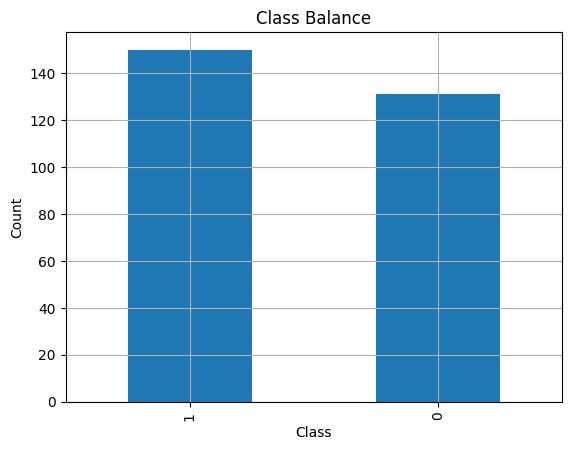

In [764]:
# Bar chart for class balance

class_counts.plot(kind="bar")

plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(True)

plt.show()

### Part (c) : Min-Max Feature Scaling #####

###### Min-Max Scaling Formula:

###### x_scaled = (x - xmin) / (xmax - xmin)

###### Feature scaling is important in KNN
###### because KNN uses distance calculations.

###### Without scaling, larger-value features
###### dominate smaller-value features.

In [765]:
# Features to scale

feature_cols = [
    "Return_1d",
    "SMA_5",
    "SMA_20",
    "Volatility_10",
    "Momentum_5"
]

In [766]:
# Manual Min-Max Scaling

scaled_df = prices_df.copy()

for col in feature_cols:

    xmin = scaled_df[col].min()
    xmax = scaled_df[col].max()

    scaled_df[col] = (scaled_df[col] - xmin) / (xmax - xmin)

scaled_df.head()

,Price,Return_1d,SMA_5,SMA_20,Volatility_10,Momentum_5,Target
0,490.180058,0.328904,0.344357,0.467401,0.306259,0.206039,0
1,478.209142,0.257818,0.316328,0.461523,0.226798,0.233485,1
2,491.303310,0.663507,0.305072,0.457837,0.546655,0.362831,0
3,489.797970,0.425076,0.300597,0.453948,0.553528,0.415115,1
4,490.883121,0.466422,0.294034,0.448630,0.538124,0.399013,0


## Problem 6 :
###  K-Nearest Neighbours (KNN) From Scratch


###### In this problem we implement KNN manually
###### using only NumPy.

###### We do NOT use scikit-learn.

###### KNN works using distance between points.

###### Euclidean Distance Formula:

###### d(x1, x2) = sqrt( Σ (x1 - x2)^2 )

###### We use the features created in Problem 5.

### Part (a) : Euclidean Distance and KNN Prediction #####

###### Steps:

###### 1. Compute distance from test point
######    to all training points

###### 2. Select k nearest neighbours

###### 3. Take majority voting

###### 4. Return predicted class

In [767]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [768]:
# Selecting features and target

X = scaled_df[[
    "Return_1d",
    "SMA_5",
    "SMA_20",
    "Volatility_10",
    "Momentum_5"
]].values

y = scaled_df["Target"].values

In [769]:
# Train-Test Split (80-20)

split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [770]:
# Euclidean Distance Function

def euclidean_distance(x1, x2):

    distance = np.sqrt(np.sum((x1 - x2) ** 2))

    return distance

In [771]:
# KNN Prediction Function

def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for test_point in X_test:

        distances = []

        for train_point in X_train:

            dist = euclidean_distance(test_point, train_point)

            distances.append(dist)

        distances = np.array(distances)

        k_indices = np.argsort(distances)[:k]

        k_labels = y_train[k_indices]

        prediction = np.bincount(k_labels).argmax()

        predictions.append(prediction)

    return np.array(predictions)

### Part (b) : Accuracy for Different k Values #####

###### We test the following values:

###### k = [3, 5, 7, 11, 15]

###### Accuracy Formula:

###### Accuracy = Correct Predictions / Total Predictions

In [772]:
# Accuracy Function

def accuracy_score(y_true, y_pred):

    accuracy = np.mean(y_true == y_pred)

    return accuracy

In [773]:
# Testing different k values

k_values = [3, 5, 7, 11, 15]

accuracies = []

for k in k_values:

    predictions = knn_predict(X_train, y_train, X_test, k)

    accuracy = accuracy_score(y_test, predictions)

    accuracies.append(accuracy)

    print("k =", k, " Accuracy =", accuracy)

k = 3  Accuracy = 0.5263157894736842
k = 5  Accuracy = 0.5263157894736842
k = 7  Accuracy = 0.49122807017543857
k = 11  Accuracy = 0.49122807017543857
k = 15  Accuracy = 0.5964912280701754


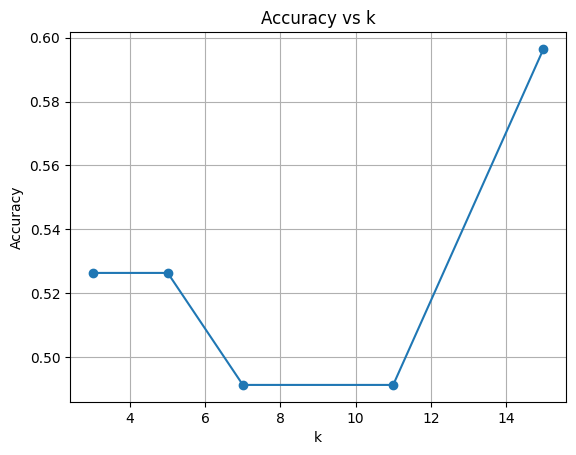

In [774]:
# Plotting Accuracy vs k

plt.plot(k_values, accuracies, marker='o')

plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [775]:
# Best k value

best_index = np.argmax(accuracies)

best_k = k_values[best_index]

print("Best k =", best_k)

Best k = 15


### Part (c) : Confusion Matrix #####

###### Confusion Matrix:

###### TP = True Positive
###### TN = True Negative
###### FP = False Positive
###### FN = False Negative

###### Precision = TP / (TP + FP)

###### Recall = TP / (TP + FN)

In [776]:
# Predictions using best k

best_predictions = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k
)

In [777]:
# Computing confusion matrix values

TP = np.sum((y_test == 1) & (best_predictions == 1))

TN = np.sum((y_test == 0) & (best_predictions == 0))

FP = np.sum((y_test == 0) & (best_predictions == 1))

FN = np.sum((y_test == 1) & (best_predictions == 0))

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

TP = 16
TN = 18
FP = 11
FN = 12


In [778]:
# Precision and Recall

precision = TP / (TP + FP)

recall = TP / (TP + FN)

print("Precision =", precision)

print("Recall =", recall)

Precision = 0.5925925925925926
Recall = 0.5714285714285714


### Conclusion

###### Precision is more important when
###### false positive trades are costly.

###### High precision means fewer wrong buy signals.

###### Recall is important when missing
###### profitable opportunities is costly.

## Problem 7 :
### Linear Regression From Scratch

###### In this problem we implement Linear Regression
###### using the Normal Equation method.

###### We use the features from Problem 5
###### and predict next-day return.

###### Linear Regression Formula:

###### y_hat = X * beta

###### Normal Equation:

###### beta = (XᵀX)^(-1) Xᵀy

### Part (a) : Normal Equation

###### Steps:

###### 1. Create feature matrix X

###### 2. Create target vector y

###### 3. Add bias column of ones

###### 4. Compute beta coefficients

###### 5. Interpret coefficients

In [779]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [780]:
# Creating continuous target variable

prices_df["Target_Return"] = prices_df["Return_1d"].shift(-1)

prices_df = prices_df.dropna().reset_index(drop=True)

In [781]:
# Feature matrix X

X = prices_df[[
    "Return_1d",
    "SMA_5",
    "SMA_20",
    "Volatility_10",
    "Momentum_5"
]].values

# Target vector y

y = prices_df["Target_Return"].values

In [782]:
# Train-Test Split

split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [783]:
# Adding bias column

ones_train = np.ones((X_train.shape[0], 1))
ones_test = np.ones((X_test.shape[0], 1))

X_train_bias = np.hstack((ones_train, X_train))
X_test_bias = np.hstack((ones_test, X_test))

In [784]:
# Normal Equation

beta = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train

print("Learned Coefficients:\n")

print(beta)

Learned Coefficients:

[ 9.05275486e-03 -4.41657191e-02  1.01973849e-04 -1.09686751e-04
 -2.44431011e-01 -9.20712498e-05]


#### Interpretation of Coefficients

###### Positive coefficient:
###### feature increases predicted return

###### Negative coefficient:
###### feature decreases predicted return

### Part (b) : Prediction and Evaluation

###### Metrics Used:

###### 1. Mean Squared Error (MSE)

###### MSE = (1/n) * Σ(yi - y_hat)^2

###### 2. R² Score

###### R² = 1 - [ Σ(yi - y_hat)^2 / Σ(yi - y_mean)^2 ]

In [785]:
# Predictions

y_pred = X_test_bias @ beta

In [786]:
# Mean Squared Error

mse = np.mean((y_test - y_pred) ** 2)

print("MSE =", mse)

MSE = 0.00035656903876890887


In [787]:
# R² Score

ss_total = np.sum((y_test - np.mean(y_test)) ** 2)

ss_residual = np.sum((y_test - y_pred) ** 2)

r2_score = 1 - (ss_residual / ss_total)

print("R² Score =", r2_score)

R² Score = 0.02263774957284803


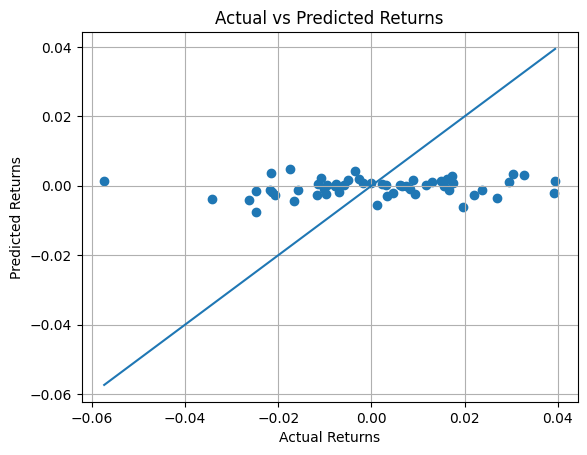

In [788]:
# Actual vs Predicted Plot

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Actual vs Predicted Returns")

plt.xlabel("Actual Returns")

plt.ylabel("Predicted Returns")

plt.grid(True)

plt.show()

### Part (c) : Gradient Descent

###### Gradient Descent Update Rule:

###### beta = beta - (eta/n) * Xᵀ(Xbeta - y)

###### We use:

###### Learning Rate = 0.01

###### Iterations = 1000

In [789]:
# Feature Scaling
X_train_scaled = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)

# Add bias column
X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]

# Gradient Descent Parameters
eta = 0.0001
iterations = 1000

n = len(X_train_bias)

# Initialize coefficients
beta_gd = np.zeros(X_train_bias.shape[1])

# Store losses
loss_history = []

In [790]:
# Training using Gradient Descent

for i in range(iterations):

    predictions = X_train_bias @ beta_gd

    errors = predictions - y_train

    gradient = (X_train_bias.T @ errors) / n

    beta_gd = beta_gd - eta * gradient

    mse_loss = np.mean(errors ** 2)

    loss_history.append(mse_loss)

In [791]:
# Gradient Descent Coefficients

print("Gradient Descent Coefficients:\n")

print(beta_gd)

Gradient Descent Coefficients:

[ 1.03080764e-04 -1.19761809e-04 -1.08874934e-05 -2.50000270e-05
 -5.36771055e-05 -1.11608368e-04]


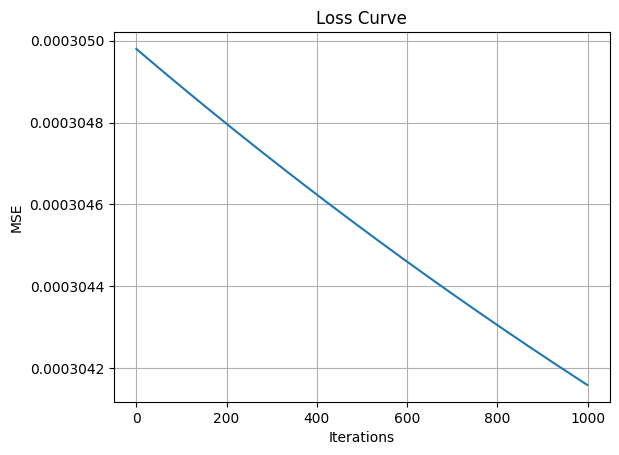

In [792]:
# Loss Curve

plt.plot(loss_history)

plt.title("Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("MSE")

plt.grid(True)

plt.show()

### Conclusion

###### The loss decreases over iterations.

###### Gradient Descent coefficients become
###### close to the Normal Equation solution.

###### This shows convergence of the model.

## Problem 8:
### Portfolio Allocation using Linear Regression


###### In this problem we connect ML predictions
###### with portfolio allocation.

###### We use the Linear Regression model
###### from Problem 7.

###### Predicted returns are used to assign
###### portfolio weights.

### Part (a) : Predict Expected Returns

###### We predict expected returns for
###### the 4 assets from Problem 1.

###### Assets:

###### 1. RELIANCE
###### 2. INFY
###### 3. HDFCBANK
###### 4. TATAMOTORS

In [793]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [794]:
# Asset price data

asset_prices = {
    "RELIANCE": [2800, 2850, 2830, 2900, 2880, 2950],

    "INFY": [1450, 1470, 1460, 1490, 1510, 1500],

    "HDFCBANK": [1600, 1580, 1610, 1625, 1615, 1640],

    "TATAMOTORS": [520, 535, 528, 540, 555, 548]
}

In [795]:
# Creating DataFrame

asset_df = pd.DataFrame(asset_prices)

asset_df

,RELIANCE,INFY,HDFCBANK,TATAMOTORS
0,2800,1450,1600,520
1,2850,1470,1580,535
2,2830,1460,1610,528
3,2900,1490,1625,540
4,2880,1510,1615,555
5,2950,1500,1640,548


In [796]:
# Creating feature matrix for each asset

predicted_returns = []

for asset in asset_df.columns:

    prices = asset_df[asset]

    returns = prices.pct_change()

    sma_5 = prices.rolling(5).mean()

    sma_20 = prices.rolling(5).mean()

    volatility_10 = returns.rolling(5).std()

    momentum_5 = prices - prices.shift(5)

    temp_df = pd.DataFrame({
        "Return_1d": returns,
        "SMA_5": sma_5,
        "SMA_20": sma_20,
        "Volatility_10": volatility_10,
        "Momentum_5": momentum_5
    })

    temp_df = temp_df.dropna()

    latest_features = temp_df.iloc[-1].values

    latest_features = np.insert(latest_features, 0, 1)

    prediction = latest_features @ beta

    predicted_returns.append(prediction)

In [797]:
# Predicted Returns Array

predicted_returns = np.array(predicted_returns)

print("Predicted Returns:\n")

print(predicted_returns)

Predicted Returns:

[-0.03203305 -0.00982826 -0.01112002 -0.00243415]


### Part (b) : Portfolio Weights

###### Weight Formula:

###### wi = max(mu_i, 0) / Σ max(mu_j, 0)

###### Only positive predicted returns
###### receive allocation.

In [798]:
# Positive predicted returns only

positive_returns = np.maximum(predicted_returns, 0)

In [799]:
# Computing portfolio weights

positive_returns = np.maximum(predicted_returns, 0)

# Checking if sum is zero

if np.sum(positive_returns) == 0:

    weights = np.array([0.25, 0.25, 0.25, 0.25])

else:

    weights = positive_returns / np.sum(positive_returns)

print("Portfolio Weights:\n")

print(weights)

Portfolio Weights:

[0.25 0.25 0.25 0.25]


In [800]:
# Checking weight sum

print("Sum of Weights =", np.sum(weights))

Sum of Weights = 1.0


### Part (c) : Backtesting

###### We compare:

###### 1. ML-driven allocation

###### 2. Equal-weight allocation

###### Equal weight means:
###### 25% allocation to each asset.

In [801]:
# Daily returns of assets

asset_returns = asset_df.pct_change().dropna()

In [802]:
# ML-driven portfolio returns

ml_returns = asset_returns.values @ weights

In [803]:
# Equal-weight portfolio returns

equal_weights = np.array([0.25, 0.25, 0.25, 0.25])

equal_returns = asset_returns.values @ equal_weights

In [804]:
# Cumulative returns

ml_cumulative = (1 + ml_returns).cumprod()

equal_cumulative = (1 + equal_returns).cumprod()

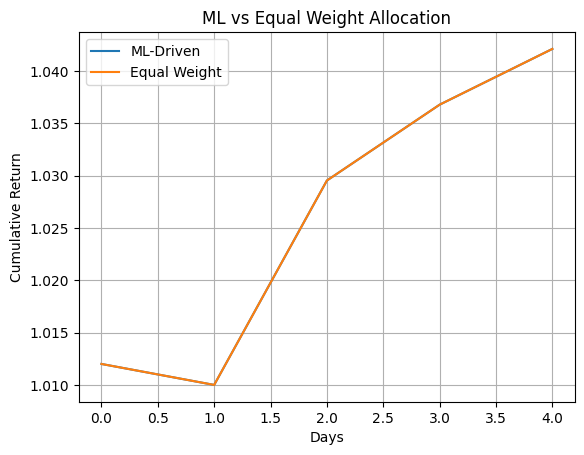

In [805]:
# Plotting comparison

plt.plot(ml_cumulative, label="ML-Driven")

plt.plot(equal_cumulative, label="Equal Weight")

plt.title("ML vs Equal Weight Allocation")

plt.xlabel("Days")

plt.ylabel("Cumulative Return")

plt.legend()

plt.grid(True)

plt.show()

### Conclusion

###### If the ML-driven curve performs better,
###### the model predictions helped allocation.

###### One limitation:

###### Linear Regression may not capture
###### complex market behaviour properly.

###### Financial markets are noisy and
###### highly unpredictable.

## Problem 9

In [806]:
# Creating X and y from scaled data

X = scaled_df[feature_cols].values

y = scaled_df["Target"].values

# Train-Test Split

split_index = int(len(X) * 0.8)

X_train_scaled = X[:split_index]
X_test_scaled = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [807]:
# Part (a): k-Fold Cross Validation

# Formula:
# Accuracy = Correct Predictions / Total Predictions

k_values = [3, 7, 11]

folds = np.array_split(X_train_scaled, 5)
target_folds = np.array_split(y_train, 5)

for k in k_values:

    accuracies = []

    for i in range(5):

        X_valid = folds[i]
        y_valid = target_folds[i]

        X_train_cv = np.concatenate([folds[j] for j in range(5) if j != i])
        y_train_cv = np.concatenate([target_folds[j] for j in range(5) if j != i])

        predictions = []

        for test_point in X_valid:

            distances = []

            for train_point in X_train_cv:

                distance = euclidean_distance(test_point, train_point)
                distances.append(distance)

            distances = np.array(distances)

            k_indices = np.argsort(distances)[:k]

            k_labels = y_train_cv[k_indices]

            prediction = np.bincount(k_labels).argmax()

            predictions.append(prediction)

        predictions = np.array(predictions)

        accuracy = np.mean(predictions == y_valid)

        accuracies.append(accuracy)

    print("k =", k)
    print("Mean Accuracy =", np.mean(accuracies))
    print("Standard Deviation =", np.std(accuracies))
    print()

k = 3
Mean Accuracy = 0.4291919191919192
Standard Deviation = 0.07928643092460635

k = 7
Mean Accuracy = 0.46909090909090906
Standard Deviation = 0.03913981749757522

k = 11
Mean Accuracy = 0.46484848484848484
Standard Deviation = 0.06683297285461463



In [808]:
# Part (b): Model Comparison Table

best_accuracy = 0.46909090909090906

comparison_df = pd.DataFrame({

    "Model": ["KNN Classifier", "Linear Regression"],

    "Accuracy/R²": [best_accuracy, r2_score],

    "MSE/N.A.": ["N.A.", mse],

    "Best Param": [7, "Normal Equation"]

})

comparison_df

,Model,Accuracy/R²,MSE/N.A.,Best Param
0,KNN Classifier,0.469091,N.A.,7
1,Linear Regression,0.022638,0.000357,Normal Equation


In [809]:
# Part (c): Conclusion

print("KNN Classifier performed better with k = 7.")

print("\nLinear Regression predicts continuous returns, while KNN predicts classes.")

print("\nTwo risks of deploying ML models in trading are:")

print("1. Overfitting - Model may perform well on training data but fail on new data.")

print("2. Look-ahead Bias - Future information may accidentally enter training data.")

KNN Classifier performed better with k = 7.

Linear Regression predicts continuous returns, while KNN predicts classes.

Two risks of deploying ML models in trading are:
1. Overfitting - Model may perform well on training data but fail on new data.
2. Look-ahead Bias - Future information may accidentally enter training data.


## Problem 10

### Part (a): Diversification

Diversification reduces portfolio risk because assets with low or negative correlation
do not move in the same direction at the same time.

When one asset falls, another asset may rise or remain stable,
which balances overall portfolio fluctuations.

In the portfolio variance formula, the correlation term reduces
the total variance when correlation is low.

Therefore, combining different assets helps investors reduce
unsystematic risk and improve portfolio stability.

### Part (b): Technical vs Fundamental Analysis

One useful fundamental feature is the Price-to-Earnings (P/E) ratio.

The P/E ratio shows whether a stock is overvalued or undervalued
compared to its earnings.

This data can be collected from financial statements
or websites such as Yahoo Finance.

The feature can then be added to the KNN dataset
along with technical indicators like SMA and volatility.

### Part (c): Curse of Dimensionality

As the number of features increases, the distance between data points
becomes less meaningful in KNN.

This makes it difficult to identify true nearest neighbours.

In financial datasets, too many features can reduce prediction accuracy
and increase computation time.

One way to reduce this problem is feature selection,
where only the most important features are used.

### Part (d): Overfitting in Backtesting

A strategy may perform well in backtesting but fail in live trading
because of overfitting.

One cause is look-ahead bias, where future information accidentally enters training data.

Another cause is survivorship bias, where only successful assets are considered.

Data snooping is also a problem when too many strategies are tested repeatedly.

Walk-forward validation can help detect these issues
by testing the strategy on unseen future data.

### Part (e): Linear Regression Assumptions

Financial return data often violates the assumptions of Linear Regression.

One common issue is autocorrelation,
where errors are related across time periods.

Another issue is heteroscedasticity,
where the variance of errors changes over time.

These problems can reduce prediction accuracy
and make the model less reliable in real market conditions.